## Library Imports and Configs 

In [1]:
import numpy as np 
import pandas as pd 
pd.set_option('display.max_columns', None)
import os
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

ROOT_PATH = "/kaggle/input/competitions/playground-series-s6e5"

train_df = pd.read_csv(os.path.join(ROOT_PATH, "train.csv"))
test_df = pd.read_csv(os.path.join(ROOT_PATH, "test.csv"))
sub_df = pd.read_csv(os.path.join(ROOT_PATH, "sample_submission.csv"))

train_df.shape, test_df.shape # (70 % train, 30 % test)

((439140, 16), (188165, 15))

In [2]:
train_df.sample(4)

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
347110,347110,D012,MEDIUM,Bahrain Grand Prix,2025,0,49,2,25.0,7,98.898,10.860,-173.959,0.628205,1.0,1.0
34963,34963,D235,MEDIUM,Dutch Grand Prix,2024,0,21,1,21.0,1,76.847,-11.926,-86.231,0.269231,2.0,0.0
108183,108183,D102,MEDIUM,Japanese Grand Prix,2025,0,5,1,5.0,14,95.912,-4.900,-84.738,0.064935,-3.0,0.0
19264,19264,AND,SOFT,Bahrain Grand Prix,2024,0,11,1,11.0,4,99.153,-2.960,-59.934,0.141026,-2.0,1.0


In [3]:
target_counts = train_df['PitNextLap'].value_counts().to_dict()
print("Percentage count of 0.0 PitNextLap")
print(target_counts[0.0] / sum(list(target_counts.values())) * 100)
print("Percentage count of 1.0 PitNextLap")
print(target_counts[1.0] / sum(list(target_counts.values())) * 100)

Percentage count of 0.0 PitNextLap
80.101789862003
Percentage count of 1.0 PitNextLap
19.898210137996994


## Data Analysis

In [4]:
cat_cols = test_df.drop(['id'], axis='columns').select_dtypes(exclude=np.number).columns
num_cols = test_df.drop(['id'], axis='columns').select_dtypes(include=np.number).columns
target_col = ['PitNextLap']

#### Numerical Column Analysis
- Violin Plot
- Correlation Plot (train, test and diff(train, test))

#### Violin Plot - Outlier Detection


******************** Analyzing Year ********************
--- Train Stats ---
Lower Bound: 2021.50 | Upper Bound: 2025.50
Outliers: Above 0 | Below 0
--- Test Stats ---
Lower Bound: 2021.50 | Upper Bound: 2025.50
Outliers: Above 0 | Below 0


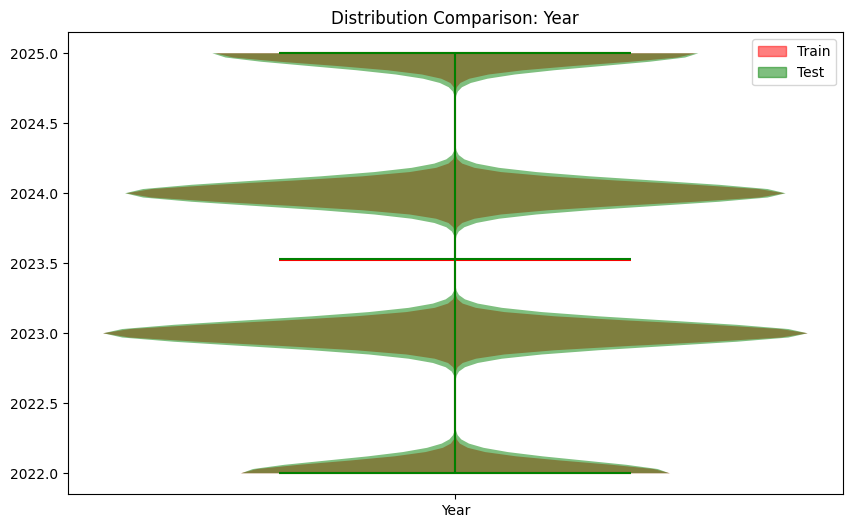


******************** Analyzing PitStop ********************
--- Train Stats ---
Lower Bound: 0.00 | Upper Bound: 0.00
Outliers: Above 59775 | Below 0
--- Test Stats ---
Lower Bound: 0.00 | Upper Bound: 0.00
Outliers: Above 25640 | Below 0


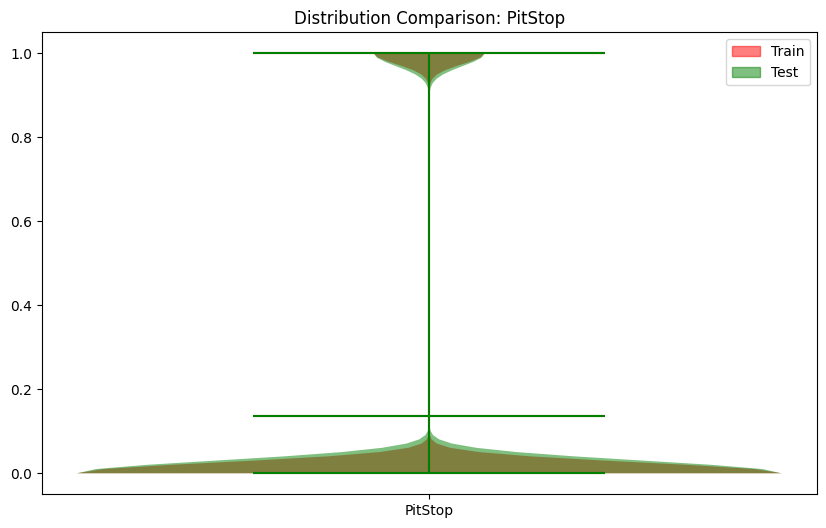


******************** Analyzing LapNumber ********************
--- Train Stats ---
Lower Bound: -31.50 | Upper Bound: 76.50
Outliers: Above 16 | Below 0
--- Test Stats ---
Lower Bound: -31.50 | Upper Bound: 76.50
Outliers: Above 4 | Below 0


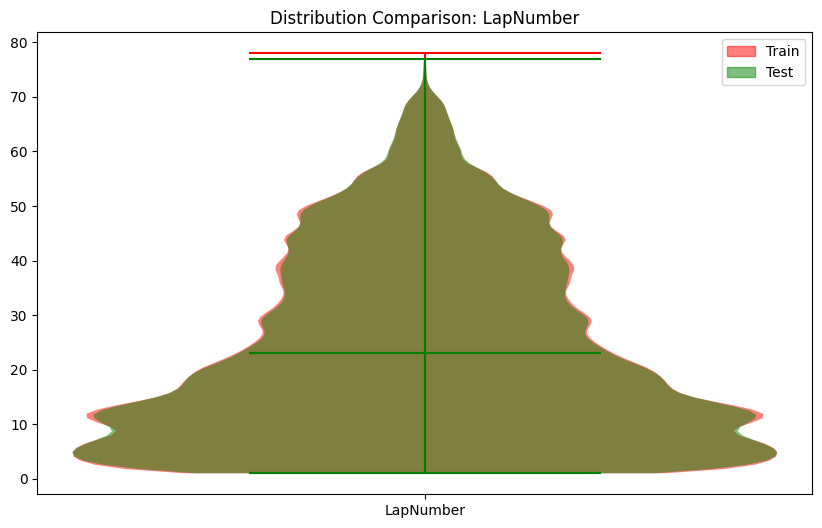


******************** Analyzing Stint ********************


In [ ]:
def box_plot(train_df, test_df, col):
    plt.figure(figsize=(10, 6))
    
    # Filter data to remove NaNs for plotting
    train_data = train_df[col].dropna()
    test_data = test_df[col].dropna()

    # Create the violin plots
    # positions=[1, 1] puts them on top of each other to show the "mixture"
    parts_train = plt.violinplot(train_data, positions=[1], showmeans=True)
    parts_test = plt.violinplot(test_data, positions=[1], showmeans=True)

    # Customize Train Plot (Red)
    for pc in parts_train['bodies']:
        pc.set_facecolor('red')
        pc.set_alpha(0.5)
    parts_train['cbars'].set_edgecolor('red')
    parts_train['cmins'].set_edgecolor('red')
    parts_train['cmaxes'].set_edgecolor('red')
    parts_train['cmeans'].set_edgecolor('red')

    # Customize Test Plot (Green)
    for pc in parts_test['bodies']:
        pc.set_facecolor('green')
        pc.set_alpha(0.5)
    parts_test['cbars'].set_edgecolor('green')
    parts_test['cmins'].set_edgecolor('green')
    parts_test['cmaxes'].set_edgecolor('green')
    parts_test['cmeans'].set_edgecolor('green')

    # Statistics Calculation Helper
    def get_stats(df, name):
        desc = df[col].describe()
        q1, q3 = desc.loc['25%'], desc.loc['75%']
        iqr = q3 - q1
        lb, ub = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        
        print(f"--- {name} Stats ---")
        print(f"Lower Bound: {lb:.2f} | Upper Bound: {ub:.2f}")
        print(f"Outliers: Above {len(df[df[col] > ub])} | Below {len(df[df[col] < lb])}")

    get_stats(train_df, "Train")
    get_stats(test_df, "Test")

    # Formatting the plot
    plt.title(f"Distribution Comparison: {col}")
    plt.xticks([1], [col])
    
    # Proxy artists for legend
    import matplotlib.patches as mpatches
    red_patch = mpatches.Patch(color='red', alpha=0.5, label='Train')
    green_patch = mpatches.Patch(color='green', alpha=0.5, label='Test')
    plt.legend(handles=[red_patch, green_patch])

    plt.show()

# Execution loop
for col in num_cols:
    print(f"\n{'*' * 20} Analyzing {col} {'*' * 20}")
    box_plot(train_df, test_df, col)

> Training and testing data hase almost same distribution of data. Here we can see some datapoints are crossing lower and upper bound, but at looking at the same distribution of training and testing we can conclude these are not really outliers.

#### Correlation Before Feature Engineering

In [ ]:
train_corr = train_df[num_cols].corr()
test_corr = test_df[num_cols].corr()
diff_corr = train_corr - test_corr

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.heatmap(train_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0], cbar=False)
axes[0].set_title("Correlation Matrix: Train", fontsize=14, fontweight='bold')

sns.heatmap(test_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1], cbar=False)
axes[1].set_title("Correlation Matrix: Test", fontsize=14, fontweight='bold')

sns.heatmap(diff_corr, annot=True, cmap='PiYG', fmt=".2f", ax=axes[2], center=0)
axes[2].set_title("Difference (Train - Test)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#### Categoricla Column Analysis
- Bar Chart - categorical distribution

In [ ]:
categories_report_train = {col: {category: float(train_df[col].value_counts()[category]) for category in train_df[col].unique()} for col in cat_cols}
categories_report_test = {col: {category: float(test_df[col].value_counts()[category]) for category in test_df[col].unique()} for col in cat_cols}

In [ ]:
for col in categories_report_train.keys():
    train_data = categories_report_train[col]
    test_data = categories_report_test[col]
    
    all_categories = sorted(list(set(train_data.keys()) | set(test_data.keys())))
    train_values = [train_data.get(cat, 0) for cat in all_categories]
    test_values = [test_data.get(cat, 0) for cat in all_categories]
    
    plt.figure(figsize=(12, 6))
    plt.bar(all_categories, train_values, color='red', alpha=0.5, label='Train')
    plt.bar(all_categories, test_values, color='green', alpha=0.5, label='Test')
    
    plt.title(f"Categorical Distribution Comparison: {col}", fontsize=14, fontweight='bold')
    plt.xlabel("Categories")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

## Feature Engineering
- Domain Knowledge
- Correlation after feature engineering

In [ ]:
train_df.head()

In [ ]:
train_df.info()

In [ ]:
def engineer_race_features(df):
    """
    Applies feature engineering for race strategy prediction.
    Handles high correlation via ratios and extracts stint-based metrics.
    """
    # Create a copy to avoid SettingWithCopyWarning
    df = df.copy()

    # 1. Handling your high correlation pair (RaceProgress / LapNumber)
    # Adding a small epsilon to avoid division by zero
    df['Progress_Per_Lap_engg'] = df['RaceProgress'] / (df['LapNumber'] + 1e-5)

    # 2. Tyre & Degradation Ratios
    # Captures the intensity of degradation relative to the distance traveled
    df['Deg_Per_Lap_engg'] = df['Cumulative_Degradation'] / (df['LapNumber'] + 1e-5)
    df['Deg_Per_TyreLife_engg'] = df['Cumulative_Degradation'] / (df['TyreLife'] + 1e-5)

    # 4. Pace Sensitivity (The "Cliff" Detector)
    # How much is the lap time changing relative to tyre age?
    df['Pace_Tyre_Sensitivity_engg'] = df['LapTime_Delta'] / (df['TyreLife'] + 1e-5)

    # 5. Strategic Flags
    # Identify if a driver is losing positions (potential pressure to pit)
    df['Losing_Ground_engg'] = (df['Position_Change'] < 0).astype(int)
    
    # Identify 'Fresh' vs 'Old' tyres based on stint start
    df['Is_Late_Stint_engg'] = (df['TyreLife'] > 20).astype(int) 

    # 6. Interaction Terms
    # Multiplying LapTime_Delta by Cumulative_Degradation to highlight 
    # laps where both pace drops and wear is high
    df['Wear_Pace_Impact_engg'] = df['LapTime_Delta'] * df['Cumulative_Degradation']

    return df




# Apply to your dataframes
train_df_eng = engineer_race_features(train_df)
test_df_eng = engineer_race_features(test_df)

# Quick check on the new columns
eng_cols = [col for col in train_df_eng.columns if '_engg' in col.lower()]
eng_num_cols = list(num_cols) + [col for col in eng_cols if '_engg' in col.lower()]
train_df_eng[eng_cols].head()

In [ ]:
train_df_eng[eng_cols].head()

#### Correlation after feature engineering

In [ ]:
train_corr_eng = train_df_eng[eng_num_cols].corr()
test_corr_eng = test_df_eng[eng_num_cols].corr()
diff_corr_eng = train_corr_eng - test_corr_eng

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.heatmap(train_corr_eng, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0], cbar=False)
axes[0].set_title("Correlation Matrix: Train", fontsize=14, fontweight='bold')

sns.heatmap(test_corr_eng, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1], cbar=False)
axes[1].set_title("Correlation Matrix: Test", fontsize=14, fontweight='bold')

sns.heatmap(diff_corr_eng, annot=True, cmap='PiYG', fmt=".2f", ax=axes[2], center=0)
axes[2].set_title("Difference (Train - Test)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Data Processing
- Encoding - (categorical data) (Label Encoding and OneHotEncoding)
- Normalization - (numerical data)

#### Encoding - Categorical data - Label Encoding and OneHotEncoding

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

label_encoder = LabelEncoder()

train_df_eng["Driver_en"] = label_encoder.fit_transform(train_df_eng['Driver'])
test_df_eng["Driver_en"] = label_encoder.transform(test_df_eng['Driver'])

train_df_eng["Race_en"] = label_encoder.fit_transform(train_df_eng['Race'])
test_df_eng["Race_en"] = label_encoder.transform(test_df_eng['Race'])

    
train_df_eng_enc = train_df_eng.drop(["Driver", "Race"], axis='columns')
test_df_eng_enc = test_df_eng.drop(["Driver", "Race"], axis='columns')

In [ ]:
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_data = one_hot_encoder.fit_transform(train_df_eng_enc[['Compound']])
encoded_df = pd.DataFrame(
    encoded_data, 
    columns=one_hot_encoder.get_feature_names_out(['Compound']),
    index=train_df_eng_enc.index
)
train_df_eng_enc_v1 = pd.concat([train_df_eng_enc, encoded_df], axis=1).drop('Compound', axis=1)


test_encoded_data = one_hot_encoder.transform(test_df_eng_enc[['Compound']])
test_encoded_df = pd.DataFrame(
    test_encoded_data, 
    columns=one_hot_encoder.get_feature_names_out(['Compound']),
    index=test_df_eng_enc.index
)
test_df_eng_enc_v1 = pd.concat([test_df_eng_enc, test_encoded_df], axis=1).drop('Compound', axis=1)

train_df_eng_enc_v1.filter(like='Compound').head()

#### Normalization (MinMax / StandardScaler)

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

class DataNormalizer:
    def __init__(self, method='standard'):
        """
        Initializes the normalizer with the chosen scaling strategy.
        method: 'minmax' or 'standard'
        """
        self.method = method
        if method == 'minmax':
            self.scaler = MinMaxScaler()
        elif method == 'standard':
            self.scaler = StandardScaler()
        else:
            raise ValueError("Method must be either 'minmax' or 'standard'")

    def fit(self, dataset, num_cols):
        """
        Learns the scaling parameters (mean/std or min/max) from the training set.
        """
        if not all(col in dataset.columns for col in num_cols):
            missing = [c for c in num_cols if c not in dataset.columns]
            raise ValueError(f"Columns missing from dataset: {missing}")
            
        self.scaler.fit(dataset[num_cols])
        print(f"Successfully fitted {self.method} scaler on: {num_cols}")

    def transform(self, dataset, num_cols):
        """
        Applies the learned parameters to scale the dataset.
        """
        df = dataset.copy()
        df[num_cols] = self.scaler.transform(df[num_cols])
        return df

    def fit_transform(self, dataset, num_cols):
        """
        Fits to the data then transforms it. Useful for the initial training set.
        """
        self.fit(dataset, num_cols)
        return self.transform(dataset, num_cols)


normalizer = DataNormalizer(method='standard')

train_df_scaled = normalizer.fit_transform(train_df_eng_enc_v1, num_cols=num_cols)
test_df_scaled = normalizer.transform(test_df_eng_enc_v1, num_cols=num_cols)

train_df_scaled.head()

In [ ]:
test_df_scaled.head()

In [ ]:
train_df_scaled.shape, test_df_scaled.shape

## Choosing Best Model 

In [ ]:
def submission(model, test_data, file_name:str):
    pred_data = test_data
    if 'id' in test_data.columns:
        pred_data = test_data.drop(['id'], axis='columns')
        print("!!!!!!!!!!!!!!!!!! Removed id column !!!!!!!!!!!!!!!!!!!")
        
    predictions = model.predict_proba(pred_data)[:, 1]
    sub_df['PitNextLap'] = predictions
    sub_df[['id', 'PitNextLap']].to_csv(file_name, index=False)
    print(f"Submissions saved to {file_name} path!!!!!!!!!!!!!!")

In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X, y = train_df_scaled.drop(['id', 'PitNextLap'], axis='columns'), train_df_scaled['PitNextLap'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
X_train.shape, y_test.shape

## Target Encoding - OOF

In [ ]:
encoded_cat_cols = [col for col in train_df_scaled.columns if '_en' in col.lower() and '_engg' not in col.lower()]
encoded_cat_cols 

In [ ]:
from sklearn.model_selection import KFold

train_df_scaled_v1 = train_df_scaled.copy()
test_df_scaled_v1 = test_df_scaled.copy()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for col in encoded_cat_cols:
    train_df_scaled_v1[f'{col}_mean'] = 0.0
    train_df_scaled_v1[f'{col}_std'] = 0.0

for train_idx, val_idx in kf.split(train_df_scaled_v1):
    train_fold = train_df_scaled_v1.iloc[train_idx]
    val_fold = train_df_scaled_v1.iloc[val_idx]

    for col in encoded_cat_cols:
        stats = train_fold.groupby(col)[target_col[0]].agg(['mean', 'std'])
        val_fold = val_fold.merge(stats, on=col, how='left')

        train_df_scaled_v1.loc[val_idx, f'{col}_mean'] = val_fold['mean'].values
        train_df_scaled_v1.loc[val_idx, f'{col}_std'] = val_fold['std'].values

        val_fold.drop(['mean', 'std'], axis=1, inplace=True)

for col in encoded_cat_cols:
    train_df_scaled_v1[[f'{col}_mean', f'{col}_std']] = train_df_scaled_v1[
        [f'{col}_mean', f'{col}_std']
    ].fillna(0)

for col in encoded_cat_cols:
    stats = train_df_scaled_v1.groupby(col)[target_col[0]].agg(['mean', 'std'])
    test_df_scaled_v1 = test_df_scaled_v1.merge(stats, on=col, how='left')

    test_df_scaled_v1[f'{col}_mean'] = test_df_scaled_v1['mean']
    test_df_scaled_v1[f'{col}_std'] = test_df_scaled_v1['std']

    test_df_scaled_v1.drop(['mean', 'std'], axis=1, inplace=True)

for col in encoded_cat_cols:
    test_df_scaled_v1[[f'{col}_mean', f'{col}_std']] = test_df_scaled_v1[
        [f'{col}_mean', f'{col}_std']
    ].fillna(0)

In [ ]:
X, y = train_df_scaled_v1.drop(['id', 'PitNextLap'], axis='columns'), train_df_scaled_v1['PitNextLap'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# cat_model_oot = CatBoostClassifier(
#     iterations=20000,
#     # learning_rate=0.1,
#     # depth=6,
#     verbose=0,
#     # random_seed=42,
#     auto_class_weights='Balanced'
# )

# cat_model_oot.fit(X_train, y_train)

# y_prob_test_cat = cat_model_oot.predict_proba(X_test)[:, 1]
# y_prob_train_cat = cat_model_oot.predict_proba(X_train)[:, 1]

# print("ROC AUC Score - CatBoost")
# print(f"Testing:  {roc_auc_score(y_test, y_prob_test_cat):.4f}")
# print(f"Training: {roc_auc_score(y_train, y_prob_train_cat):.4f}")

In [ ]:
cat_model_oot = CatBoostClassifier(
    iterations=20000,
    verbose=0,
    auto_class_weights='Balanced'
)

cat_model_oot.fit(X, y)

In [ ]:
submission(cat_model_oot, test_df_scaled_v1, file_name="submission.csv")

## Meta Stacking

In [ ]:
# from sklearn.ensemble import StackingClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import roc_auc_score
# from catboost import CatBoostClassifier
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier


# count_neg = (y_train == 0).sum()
# count_pos = (y_train == 1).sum()
# scale_weight = count_neg / count_pos

# base_models = [
#     ('catboost', CatBoostClassifier(auto_class_weights='Balanced', verbose=0, iterations=20000)),
#     ('xgb', XGBClassifier(scale_pos_weight=scale_weight, random_state=42)),
#     ('lgbm', LGBMClassifier())
# ]

# meta_learner = LogisticRegression()

# stacking_model = StackingClassifier(
#     estimators=base_models,
#     final_estimator=meta_learner,
#     cv=5, 
#     stack_method='predict_proba',
#     n_jobs=-1
# )

# print("Training Stacking Ensemble...")
# stacking_model.fit(X, y)

# # 5. Evaluate the results
# y_prob_stack = stacking_model.predict_proba(X_test)[:, 1]
# stack_score = roc_auc_score(y_test, y_prob_stack)

# print(f"ROC AUC Score - Meta Stacking: {stack_score:.4f}")

In [ ]:
# 6. Generate Submission [1]
# submission(stacking_model, test_df_scaled_v1, file_name="stacking_submission_20K_iterations.csv")